# 🏭 Smart Industrial Maintenance System — Full Pipeline
## FSE 570 Capstone | Arizona State University

**End-to-end predictive maintenance** using the **NASA C-MAPSS Turbofan Degradation Dataset** (FD001–FD004).

### Models:
1. **LSTM Temporal Autoencoder** — Anomaly Detection
2. **LSTM Predictor with Attention** — Failure Probability
3. **XGBoost Regression** — Remaining Useful Life (RUL)
4. **Bayesian Weibull Survival** — Time-to-Failure with Uncertainty
5. **MILP Optimizer** — Maintenance Scheduling

### Pipeline:
`Raw Sensor Data → Preprocessing + Synthetic Augmentation → Model Training → Inference → MILP Scheduling → Visualization`

> ⚠️ **Runtime**: Set to **T4 GPU** via `Runtime → Change runtime type → T4 GPU`

---
## 1. Environment Setup

In [ ]:
# Install dependencies
%pip install -q torch torchvision xgboost lifelines shap pulp scipy scikit-learn matplotlib seaborn kagglehub jupytext

In [2]:
import os
import sys
import time
import warnings
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             f1_score, precision_score, recall_score, roc_auc_score)
import xgboost as xgb
from lifelines import WeibullAFTFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from pulp import (LpProblem, LpMinimize, LpVariable, LpBinary,
                  lpSum, PULP_CBC_CMD, LpStatus, value)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🔧 Device: cuda
🎮 GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
💾 VRAM: 4.3 GB


---
## 2. Configuration

In [3]:
_SENSORS_TO_DROP = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]

class Config:
    """Central configuration for the entire pipeline."""
    # Paths
    PROJECT_ROOT = os.path.dirname(os.path.abspath(os.getcwd()))
    if os.path.basename(PROJECT_ROOT) == "notebooks":
        PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
    DATA_DIR = os.path.join(PROJECT_ROOT, "data")
    RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
    PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
    MODELS_DIR = os.path.join(PROJECT_ROOT, os.path.join("models", "saved"))

    for d in [RAW_DATA_DIR, PROCESSED_DATA_DIR, MODELS_DIR]:
        os.makedirs(d, exist_ok=True)

    # Device
    DEVICE = DEVICE
    RANDOM_SEED = 42

    # C-MAPSS Dataset
    CMAPSS_DATASET = "behrad3d/nasa-cmaps"
    CMAPSS_SUBSETS = ["FD001", "FD002", "FD003", "FD004"]
    CMAPSS_COLUMNS = (
        ["unit_id", "cycle"] +
        [f"op_setting_{i}" for i in range(1, 4)] +
        [f"sensor_{i}" for i in range(1, 22)]
    )
    SENSORS_TO_DROP = list(_SENSORS_TO_DROP)
    OP_SETTINGS_TO_DROP = ["op_setting_3"]
    ACTIVE_SENSORS = [f"sensor_{i}" for i in range(1, 22)
                      if f"sensor_{i}" not in _SENSORS_TO_DROP]

    # Preprocessing
    SEQUENCE_LENGTH = 30
    MAX_RUL = 125
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15

    # Synthetic Augmentation
    SYNTHETIC_AUGMENT = True
    SYNTHETIC_TARGET_RATIO = 0.30
    SYNTHETIC_NOISE_LEVEL = 0.03
    SYNTHETIC_DEGRADATION_MODELS = ["exponential", "linear", "polynomial"]

    # LSTM Autoencoder
    AE_HIDDEN_DIM = 64
    AE_LATENT_DIM = 32
    AE_NUM_LAYERS = 2
    AE_DROPOUT = 0.2
    AE_LEARNING_RATE = 1e-3
    AE_EPOCHS = 50
    AE_BATCH_SIZE = 64
    AE_ANOMALY_THRESHOLD_SIGMA = 3.0

    # LSTM Predictor
    PRED_HIDDEN_DIM = 64
    PRED_NUM_LAYERS = 2
    PRED_DROPOUT = 0.3
    PRED_LEARNING_RATE = 1e-3
    PRED_EPOCHS = 50
    PRED_BATCH_SIZE = 64
    PRED_FAILURE_HORIZON = 30

    # XGBoost
    XGB_PARAMS = {
        "n_estimators": 200, "max_depth": 6, "learning_rate": 0.1,
        "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3,
        "reg_alpha": 0.1, "reg_lambda": 1.0, "random_state": 42,
    }
    if torch.cuda.is_available():
        XGB_PARAMS["device"] = "cuda"
        XGB_PARAMS["tree_method"] = "hist"

    # Survival
    SURVIVAL_CONFIDENCE_LEVELS = [0.90, 0.95]

    # MILP
    MAX_CONCURRENT_CREWS = 3
    DOWNTIME_COST_PER_HOUR = 10000
    MAINTENANCE_COST_BASE = 2000
    SAFETY_RISK_THRESHOLD = 0.7
    SCHEDULING_HORIZON = 10

    # Risk
    RISK_LEVELS = {
        "critical": {"threshold": 0.7, "label": "Service Immediately", "color": "#FF4444"},
        "elevated": {"threshold": 0.4, "label": "Schedule Soon", "color": "#FFAA00"},
        "normal":   {"threshold": 0.0, "label": "Continue Monitoring", "color": "#44BB44"},
    }

cfg = Config()

# Auto-adjust batches for low-VRAM GPUs (e.g., 4 GB cards).
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if vram_gb <= 4.5:
        cfg.AE_BATCH_SIZE = min(cfg.AE_BATCH_SIZE, 16)
        cfg.PRED_BATCH_SIZE = min(cfg.PRED_BATCH_SIZE, 16)
        print(f"⚙️ Low-VRAM mode enabled ({vram_gb:.1f} GB): "
              f"AE_BATCH_SIZE={cfg.AE_BATCH_SIZE}, PRED_BATCH_SIZE={cfg.PRED_BATCH_SIZE}")

print("✅ Configuration loaded")
print(f"   Subsets: {cfg.CMAPSS_SUBSETS}")
print(f"   Split: {cfg.TRAIN_RATIO:.0%} / {cfg.VAL_RATIO:.0%} / {cfg.TEST_RATIO:.0%}")
print(f"   Synthetic augmentation: {cfg.SYNTHETIC_AUGMENT} ({cfg.SYNTHETIC_TARGET_RATIO:.0%} target)")

⚙️ Low-VRAM mode enabled (4.3 GB): AE_BATCH_SIZE=16, PRED_BATCH_SIZE=16
✅ Configuration loaded
   Subsets: ['FD001', 'FD002', 'FD003', 'FD004']
   Split: 70% / 15% / 15%
   Synthetic augmentation: True (30% target)


---
## 3. Download & Load C-MAPSS Dataset

Downloads the **NASA C-MAPSS Turbofan Engine Degradation Simulation Dataset** (FD001–FD004).
Uses direct URL download with Kaggle API fallback. No authentication needed for direct download.

> **Note**: Direct download requires no authentication. If it fails, `kaggle.json` credentials
> are used. If all else fails, synthetic fallback data is generated so the pipeline still runs.

In [4]:
import zipfile
import urllib.request

DIRECT_DOWNLOAD_URLS = [
    "https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip",
    "https://storage.googleapis.com/kaggle-data-sets/131118/598048/bundle/archive.zip",
]

def _flatten_extracted(output_dir):
    for root, dirs, files in os.walk(output_dir):
        for f in files:
            if f.endswith('.zip'):
                nested_zip = os.path.join(root, f)
                try:
                    with zipfile.ZipFile(nested_zip, 'r') as zf:
                        zf.extractall(root)
                    os.remove(nested_zip)
                except zipfile.BadZipFile:
                    pass
    for root, dirs, files in os.walk(output_dir):
        if root == output_dir:
            continue
        for f in files:
            src = os.path.join(root, f)
            dst = os.path.join(output_dir, f)
            if not os.path.exists(dst):
                os.rename(src, dst)
    for root, dirs, files in os.walk(output_dir, topdown=False):
        if root != output_dir:
            try:
                os.rmdir(root)
            except OSError:
                pass

def _generate_fallback_data(output_dir):
    np.random.seed(42)
    print("[DOWNLOAD] Generating synthetic fallback data (100 units per subset)...")
    for subset in cfg.CMAPSS_SUBSETS:
        rows = []
        for unit_id in range(1, 101):
            n_cycles = np.random.randint(120, 360)
            for cycle in range(1, n_cycles + 1):
                row = [unit_id, cycle,
                       np.random.normal(0, 0.002), np.random.normal(0, 0.0003), 100.0]
                degradation = (cycle / n_cycles) ** 1.5
                for s in range(21):
                    base = 50 + s * 10
                    trend = degradation * np.random.uniform(5, 20) * (1 if s % 2 == 0 else -1)
                    row.append(base + trend + np.random.normal(0, 0.5))
                rows.append(row)
        df = pd.DataFrame(rows)
        df.to_csv(os.path.join(output_dir, f"train_{subset}.txt"), sep=" ", header=False, index=False)
    print("[DOWNLOAD] Fallback data generated.")

def download_cmapss():
    output_dir = cfg.RAW_DATA_DIR
    os.makedirs(output_dir, exist_ok=True)
    existing = [f for f in os.listdir(output_dir)
                if f.endswith(('.txt', '.csv')) and os.path.getsize(os.path.join(output_dir, f)) > 1000]
    if existing:
        print(f"✅ Dataset already present ({len(existing)} files).")
        return

    print("📥 Attempting direct download...")
    for url in DIRECT_DOWNLOAD_URLS:
        try:
            zip_path = os.path.join(output_dir, "CMAPSSData.zip")
            urllib.request.urlretrieve(url, zip_path)
            if not zipfile.is_zipfile(zip_path):
                os.remove(zip_path)
                continue
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(output_dir)
            os.remove(zip_path)
            _flatten_extracted(output_dir)
            data_files = [f for f in os.listdir(output_dir)
                         if f.endswith('.txt') and os.path.getsize(os.path.join(output_dir, f)) > 1000]
            if data_files:
                print("✅ Direct download successful!")
                return
        except Exception as e:
            print(f"   Direct download failed: {e}")
            if os.path.exists(zip_path):
                os.remove(zip_path)

    try:
        import kagglehub
        print("📥 Trying kagglehub...")
        path = kagglehub.dataset_download(cfg.CMAPSS_DATASET)
        _flatten_extracted(path)
        import shutil
        for f in os.listdir(path):
            src = os.path.join(path, f)
            if os.path.isfile(src):
                shutil.copy2(src, os.path.join(output_dir, f))
        print("✅ kagglehub download successful!")
        return
    except Exception as e:
        print(f"   kagglehub failed: {e}")

    print("⚠️ All downloads failed. Generating synthetic fallback data...")
    _generate_fallback_data(output_dir)


def load_cmapss_train(subset="FD001"):
    data_dir = cfg.RAW_DATA_DIR
    possible_names = [f"train_{subset}.txt", f"train_{subset}.csv", "PM_train.txt"]
    filepath = None
    for name in possible_names:
        candidate = os.path.join(data_dir, name)
        if os.path.exists(candidate):
            filepath = candidate
            break
    if filepath is None:
        for root, dirs, files in os.walk(data_dir):
            for f in files:
                if "train" in f.lower() and subset.lower() in f.lower():
                    filepath = os.path.join(root, f)
                    break
            if filepath:
                break
    if filepath is None:
        raise FileNotFoundError(f"Could not find training file for {subset} in {data_dir}")

    df = pd.read_csv(filepath, sep=r"\s+", header=None)
    cols = cfg.CMAPSS_COLUMNS
    if len(df.columns) >= len(cols):
        df = df.iloc[:, :len(cols)]
    df.columns = cols[:len(df.columns)]

    max_cycles = df.groupby("unit_id")["cycle"].max().reset_index()
    max_cycles.columns = ["unit_id", "max_cycle"]
    df = df.merge(max_cycles, on="unit_id")
    df["RUL"] = (df["max_cycle"] - df["cycle"]).clip(upper=cfg.MAX_RUL)
    df.drop("max_cycle", axis=1, inplace=True)
    print(f"[LOAD] {subset}: {df['unit_id'].nunique()} units, {len(df)} rows")
    return df


def load_cmapss_all_subsets():
    dfs = []
    unit_offset = 0
    for subset in cfg.CMAPSS_SUBSETS:
        try:
            df = load_cmapss_train(subset)
            df["subset"] = subset
            df["unit_id"] = df["unit_id"] + unit_offset
            unit_offset = df["unit_id"].max()
            dfs.append(df)
        except FileNotFoundError:
            print(f"⚠️ {subset} not found, skipping.")
    if not dfs:
        raise FileNotFoundError("No C-MAPSS subsets found. Run download_cmapss() first.")
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"[LOAD] Combined: {df_all['unit_id'].nunique()} units, {len(df_all)} rows")
    return df_all


download_cmapss()

✅ Dataset already present (11 files).


---
## 4. Load All Subsets

In [5]:
df_raw = load_cmapss_all_subsets()

print(f"\nLoaded {df_raw['unit_id'].nunique()} units, {len(df_raw)} rows")
print(f"Subsets: {cfg.CMAPSS_SUBSETS}")
print(f"Columns: {list(df_raw.columns[:10])}...")
print(f"RUL range: [{df_raw['RUL'].min()}, {df_raw['RUL'].max()}]")

[LOAD] FD001: 100 units, 20631 rows
[LOAD] FD002: 260 units, 53759 rows
[LOAD] FD003: 100 units, 24720 rows
[LOAD] FD004: 249 units, 61249 rows
[LOAD] Combined: 709 units, 160359 rows

Loaded 709 units, 160359 rows
Subsets: ['FD001', 'FD002', 'FD003', 'FD004']
Columns: ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']...
RUL range: [0, 125]


---
## 5. Preprocessing & Synthetic Augmentation

1. Drop constant / near-constant sensors
2. Handle missing values
3. Temporal train / val / test split by unit ID (34 / 33 / 33 %)
4. **Synthetic augmentation** — injects ~30 % new C-MAPSS-style degradation trajectories into **training only**
5. Min-max normalization (fit on augmented training, transform val / test)
6. Sliding window sequences (30-cycle windows) for LSTM input

In [6]:
class SyntheticCMAPSSGenerator:
    """Generate synthetic C-MAPSS sensor degradation trajectories from real-data statistics."""

    def __init__(self, noise_level=None, seed=None):
        self.noise_level = noise_level or cfg.SYNTHETIC_NOISE_LEVEL
        self.rng = np.random.default_rng(seed or cfg.RANDOM_SEED + 1000)
        self.sensor_stats = None
        self.op_stats = None
        self.sensor_cov = None
        self.sensor_cols = []
        self.op_cols = []

    def fit(self, df_real):
        self.sensor_cols = [c for c in df_real.columns
                            if c.startswith("sensor_") and c not in cfg.SENSORS_TO_DROP]
        self.op_cols = [c for c in df_real.columns
                        if c.startswith("op_setting_") and c not in cfg.OP_SETTINGS_TO_DROP]

        phase_dfs = {"early": [], "mid": [], "late": []}
        for _, group in df_real.groupby("unit_id"):
            group = group.sort_values("cycle")
            n = len(group)
            third = max(1, n // 3)
            phase_dfs["early"].append(group.iloc[:third])
            phase_dfs["mid"].append(group.iloc[third:2*third])
            phase_dfs["late"].append(group.iloc[2*third:])

        self.sensor_stats = {}
        for phase, dfs in phase_dfs.items():
            combined = pd.concat(dfs)
            self.sensor_stats[phase] = {
                "mean": combined[self.sensor_cols].mean().values,
                "std": combined[self.sensor_cols].std().fillna(0).values,
            }

        self.sensor_cov = df_real[self.sensor_cols].cov().values
        self.sensor_cov += np.eye(len(self.sensor_cols)) * 1e-6

        self.op_stats = {
            "mean": df_real[self.op_cols].mean().values,
            "std": df_real[self.op_cols].std().fillna(0).values,
        }

        cycle_counts = df_real.groupby("unit_id")["cycle"].max()
        self.lifetime_mean = cycle_counts.mean()
        self.lifetime_std = cycle_counts.std()
        self.lifetime_min = cycle_counts.min()
        self.lifetime_max = cycle_counts.max()

    def generate(self, n_units, start_unit_id=1):
        if self.sensor_stats is None:
            raise RuntimeError("Call fit() first with real data.")

        rows = []
        for i in range(n_units):
            unit_id = start_unit_id + i
            n_cycles = int(np.clip(
                self.rng.normal(self.lifetime_mean, self.lifetime_std),
                self.lifetime_min,
                self.lifetime_max * 1.2,
            ))
            n_cycles = max(50, n_cycles)
            deg_model = self.rng.choice(cfg.SYNTHETIC_DEGRADATION_MODELS)

            t = np.linspace(0, 1, n_cycles)
            if deg_model == "exponential":
                degradation = (np.exp(3 * t) - 1) / (np.exp(3) - 1)
            elif deg_model == "linear":
                degradation = t
            else:
                power = self.rng.uniform(1.5, 3.0)
                degradation = t ** power

            early_mean = self.sensor_stats["early"]["mean"]
            late_mean = self.sensor_stats["late"]["mean"]

            for cycle_idx in range(n_cycles):
                d = degradation[cycle_idx]
                cycle = cycle_idx + 1
                sensor_means = early_mean + d * (late_mean - early_mean)
                noise = self.rng.multivariate_normal(
                    np.zeros(len(self.sensor_cols)),
                    self.sensor_cov * self.noise_level,
                )
                sensor_values = sensor_means + noise
                op_values = self.rng.normal(self.op_stats["mean"], self.op_stats["std"])

                row = {"unit_id": unit_id, "cycle": cycle}
                for j, col in enumerate(self.op_cols):
                    row[col] = op_values[j]
                for j, col in enumerate(self.sensor_cols):
                    row[col] = sensor_values[j]
                rows.append(row)

        df_synth = pd.DataFrame(rows)
        for col in cfg.SENSORS_TO_DROP:
            if col not in df_synth.columns:
                df_synth[col] = 0.0
        for col in cfg.OP_SETTINGS_TO_DROP:
            if col not in df_synth.columns:
                df_synth[col] = 0.0

        max_cycles = df_synth.groupby("unit_id")["cycle"].max().reset_index()
        max_cycles.columns = ["unit_id", "max_cycle"]
        df_synth = df_synth.merge(max_cycles, on="unit_id")
        df_synth["RUL"] = (df_synth["max_cycle"] - df_synth["cycle"]).clip(upper=cfg.MAX_RUL)
        df_synth.drop("max_cycle", axis=1, inplace=True)

        expected_cols = ["unit_id", "cycle"]
        expected_cols += [f"op_setting_{i}" for i in range(1, 4)]
        expected_cols += [f"sensor_{i}" for i in range(1, 22)]
        expected_cols += ["RUL"]
        df_synth = df_synth[[c for c in expected_cols if c in df_synth.columns]]
        return df_synth

    def generate_for_augmentation(self, df_train):
        self.fit(df_train)
        real_rows = len(df_train)
        target_ratio = cfg.SYNTHETIC_TARGET_RATIO
        target_synthetic_rows = int(target_ratio * real_rows / (1 - target_ratio))
        avg_rows_per_unit = real_rows / df_train["unit_id"].nunique()
        n_units = max(1, int(target_synthetic_rows / avg_rows_per_unit))
        start_id = int(df_train["unit_id"].max()) + 1
        return self.generate(n_units, start_unit_id=start_id)


class DataPreprocessor:
    """Preprocess C-MAPSS data for sequential models."""

    def __init__(self):
        self.scaler = MinMaxScaler()
        self.feature_columns = []
        self.fitted = False

    def drop_constant_sensors(self, df, variance_threshold=0.001):
        sensor_cols = [c for c in df.columns if c.startswith("sensor_") or c.startswith("op_setting_")]
        cols_to_drop = [c for c in cfg.SENSORS_TO_DROP + cfg.OP_SETTINGS_TO_DROP if c in df.columns]
        for col in sensor_cols:
            if col not in cols_to_drop and df[col].std() < variance_threshold:
                cols_to_drop.append(col)
        return df.drop(columns=cols_to_drop, errors="ignore")

    def handle_missing_values(self, df):
        if df.isnull().sum().sum() > 0:
            df = df.groupby("unit_id", group_keys=False).apply(lambda g: g.ffill().bfill())
        return df

    def temporal_split(self, df):
        unit_ids = df["unit_id"].unique()
        np.random.seed(cfg.RANDOM_SEED)
        np.random.shuffle(unit_ids)
        n = len(unit_ids)
        n_train = int(n * cfg.TRAIN_RATIO)
        n_val = int(n * cfg.VAL_RATIO)
        train_units = unit_ids[:n_train]
        val_units = unit_ids[n_train:n_train + n_val]
        test_units = unit_ids[n_train + n_val:]
        return (
            df[df["unit_id"].isin(train_units)].copy(),
            df[df["unit_id"].isin(val_units)].copy(),
            df[df["unit_id"].isin(test_units)].copy(),
        )

    def normalize(self, df, fit=True):
        exclude = ["unit_id", "cycle", "RUL"]
        self.feature_columns = [c for c in df.columns if c not in exclude]
        df_out = df.copy()
        if fit:
            df_out[self.feature_columns] = self.scaler.fit_transform(df[self.feature_columns])
            self.fitted = True
        else:
            df_out[self.feature_columns] = self.scaler.transform(df[self.feature_columns])
        return df_out

    def create_sequences(self, df, sequence_length=None):
        seq_len = sequence_length or cfg.SEQUENCE_LENGTH
        sequences, labels, unit_ids = [], [], []
        for unit_id, group in df.groupby("unit_id"):
            group = group.sort_values("cycle")
            features = group[self.feature_columns].values
            rul = group["RUL"].values
            if len(features) < seq_len:
                pad_len = seq_len - len(features)
                features_padded = np.vstack([np.zeros((pad_len, features.shape[1])), features])
                sequences.append(features_padded)
                labels.append(rul[-1])
                unit_ids.append(unit_id)
            else:
                for i in range(len(features) - seq_len + 1):
                    sequences.append(features[i:i + seq_len])
                    labels.append(rul[i + seq_len - 1])
                    unit_ids.append(unit_id)
        return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.float32), np.array(unit_ids)

    def create_binary_labels(self, rul_values, horizon=None):
        h = horizon or cfg.PRED_FAILURE_HORIZON
        return (rul_values <= h).astype(np.float32)

    def fit_transform(self, df, augment=None):
        augment = cfg.SYNTHETIC_AUGMENT if augment is None else augment
        df = self.drop_constant_sensors(df)
        df = self.handle_missing_values(df)
        df_train, df_val, df_test = self.temporal_split(df)

        if augment:
            generator = SyntheticCMAPSSGenerator()
            df_synth = generator.generate_for_augmentation(df_train)
            cols_to_drop = [c for c in cfg.SENSORS_TO_DROP + cfg.OP_SETTINGS_TO_DROP if c in df_synth.columns]
            df_synth = df_synth.drop(columns=cols_to_drop, errors="ignore")
            missing_cols = set(df_train.columns) - set(df_synth.columns)
            for col in missing_cols:
                df_synth[col] = 0.0
            df_synth = df_synth[df_train.columns]
            df_train = pd.concat([df_train, df_synth], ignore_index=True)

        df_train = self.normalize(df_train, fit=True)
        df_val = self.normalize(df_val, fit=False)
        df_test = self.normalize(df_test, fit=False)

        result = {}
        for name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
            X, y_rul, unit_ids = self.create_sequences(split_df)
            y_binary = self.create_binary_labels(y_rul)
            result[name] = {"X": X, "y_rul": y_rul, "y_binary": y_binary, "unit_ids": unit_ids}
            print(f"[PREPROCESS] {name}: X={X.shape}, failure_rate={y_binary.mean():.2%}, "
                  f"RUL=[{y_rul.min():.0f}, {y_rul.max():.0f}]")
        return result

In [7]:
df_for_preprocess = df_raw.drop(columns=["subset"], errors="ignore")
preprocessor = DataPreprocessor()
data = preprocessor.fit_transform(df_for_preprocess, augment=cfg.SYNTHETIC_AUGMENT)

X_train = data["train"]["X"]
y_train_rul = data["train"]["y_rul"]
y_train_bin = data["train"]["y_binary"]
X_val = data["val"]["X"]
y_val_rul = data["val"]["y_rul"]
y_val_bin = data["val"]["y_binary"]
X_test = data["test"]["X"]
y_test_rul = data["test"]["y_rul"]
y_test_bin = data["test"]["y_binary"]

n_features = X_train.shape[2]
print(f"\n{'Split':<8} {'Sequences':>10} {'Failure%':>10} {'RUL range':>15}")
print("-" * 45)
for name, d in data.items():
    print(f"{name:<8} {d['X'].shape[0]:>10} {d['y_binary'].mean():>10.2%} "
          f"[{d['y_rul'].min():.0f}, {d['y_rul'].max():.0f}]")

[PREPROCESS] train: X=(138803, 30, 16), failure_rate=15.81%, RUL=[0, 125]
[PREPROCESS] val: X=(21887, 30, 16), failure_rate=15.01%, RUL=[0, 125]
[PREPROCESS] test: X=(21068, 30, 16), failure_rate=15.74%, RUL=[0, 125]

Split     Sequences   Failure%       RUL range
---------------------------------------------
train        138803     15.81% [0, 125]
val           21887     15.01% [0, 125]
test          21068     15.74% [0, 125]


---
## 6. Preprocessing Status

The rolling features, split, normalization, sequence generation, and synthetic augmentation
are already handled by the C-MAPSS preprocessor above.

In [8]:
# Preprocessing, normalization, splitting, and synthetic augmentation are now handled
# by DataPreprocessor.fit_transform() in the previous cell.
print("✅ Preprocessing pipeline already completed above.")

✅ Preprocessing pipeline already completed above.


In [9]:
# Sequence generation and binary labels are already produced by DataPreprocessor.fit_transform().
print("✅ Sequences already created above.")
print(f"   Train: X={X_train.shape}, failure_rate={y_train_bin.mean():.2%}")
print(f"   Val:   X={X_val.shape}, failure_rate={y_val_bin.mean():.2%}")
print(f"   Test:  X={X_test.shape}, failure_rate={y_test_bin.mean():.2%}")

✅ Sequences already created above.
   Train: X=(138803, 30, 16), failure_rate=15.81%
   Val:   X=(21887, 30, 16), failure_rate=15.01%
   Test:  X=(21068, 30, 16), failure_rate=15.74%


---
## 7. Model 1: LSTM Temporal Autoencoder (Anomaly Detection)

In [10]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, seq_len, num_layers, dropout):
        super().__init__()
        self.seq_len = seq_len
        self.fc = nn.Linear(latent_dim, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, latent):
        h = self.fc(latent).unsqueeze(1).repeat(1, self.seq_len, 1)
        o, _ = self.lstm(h)
        return self.out(o)

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden=64, latent=32, layers=2, dropout=0.2, seq_len=30):
        super().__init__()
        self.encoder = LSTMEncoder(input_dim, hidden, latent, layers, dropout)
        self.decoder = LSTMDecoder(latent, hidden, input_dim, seq_len, layers, dropout)
        self.threshold = None
        self.input_dim = input_dim

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def compute_anomaly_score(self, x):
        self.eval()
        if not isinstance(x, torch.Tensor):
            x = torch.as_tensor(x, dtype=torch.float32)

        batch_size = cfg.AE_BATCH_SIZE
        scores = []
        with torch.no_grad():
            for start in range(0, len(x), batch_size):
                batch_x = x[start:start + batch_size].to(cfg.DEVICE)
                recon = self.forward(batch_x)
                mse = ((batch_x - recon) ** 2).mean(dim=(1, 2))
                scores.append(mse.cpu().numpy())

        return np.concatenate(scores, axis=0) if scores else np.array([])

    def set_threshold(self, scores, sigma=3.0):
        self.threshold = np.mean(scores) + sigma * np.std(scores)
        print(f"   Threshold: {self.threshold:.6f}")
        return self.threshold

    def detect_anomalies(self, x):
        scores = self.compute_anomaly_score(x)
        return scores, scores > self.threshold

In [11]:
# Train Autoencoder on healthy data
print("=" * 60)
print("🔴 TRAINING: LSTM AUTOENCODER (Anomaly Detection)")
print("=" * 60)

ae = LSTMAutoencoder(n_features, seq_len=cfg.SEQUENCE_LENGTH).to(cfg.DEVICE)
ae_opt = torch.optim.Adam(ae.parameters(), lr=cfg.AE_LEARNING_RATE)
ae_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(ae_opt, patience=5, factor=0.5)
ae_criterion = nn.MSELoss()

healthy_mask = y_train_rul > (cfg.MAX_RUL * 0.5)
X_healthy = X_train[healthy_mask]
print(f"   Healthy samples: {len(X_healthy)}/{len(X_train)} ({len(X_healthy)/len(X_train):.0%})")

if len(X_healthy) < 10:
    healthy_mask = y_train_rul > np.median(y_train_rul)
    X_healthy = X_train[healthy_mask]
    print(f"   Fallback healthy: {len(X_healthy)}/{len(X_train)}")

loader = DataLoader(TensorDataset(torch.FloatTensor(X_healthy), torch.FloatTensor(X_healthy)),
                    batch_size=cfg.AE_BATCH_SIZE, shuffle=True)
for epoch in range(cfg.AE_EPOCHS):
    ae.train()
    total_loss = 0
    for bx, _ in loader:
        bx = bx.to(cfg.DEVICE)
        recon = ae(bx)
        loss = ae_criterion(recon, bx)
        ae_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(ae.parameters(), 1.0)
        ae_opt.step()
        total_loss += loss.item() * len(bx)
    avg = total_loss / len(X_healthy)
    ae_sched.step(avg)
    if (epoch + 1) % 10 == 0:
        print(f"   Epoch {epoch+1}/{cfg.AE_EPOCHS} — Loss: {avg:.6f}")

train_scores = ae.compute_anomaly_score(torch.FloatTensor(X_healthy))
ae.set_threshold(train_scores)
torch.save({"model_state": ae.state_dict(), "threshold": ae.threshold,
            "input_dim": n_features, "hidden_dim": cfg.AE_HIDDEN_DIM,
            "latent_dim": cfg.AE_LATENT_DIM, "num_layers": cfg.AE_NUM_LAYERS,
            "seq_len": cfg.SEQUENCE_LENGTH},
           os.path.join(cfg.MODELS_DIR, "autoencoder.pt"))
print("✅ Autoencoder trained and saved")

🔴 TRAINING: LSTM AUTOENCODER (Anomaly Detection)
   Healthy samples: 94199/138803 (68%)
   Epoch 10/50 — Loss: 0.013427
   Epoch 20/50 — Loss: 0.009179
   Epoch 30/50 — Loss: 0.006544
   Epoch 40/50 — Loss: 0.004306
   Epoch 50/50 — Loss: 0.004641
   Threshold: 0.011526
✅ Autoencoder trained and saved


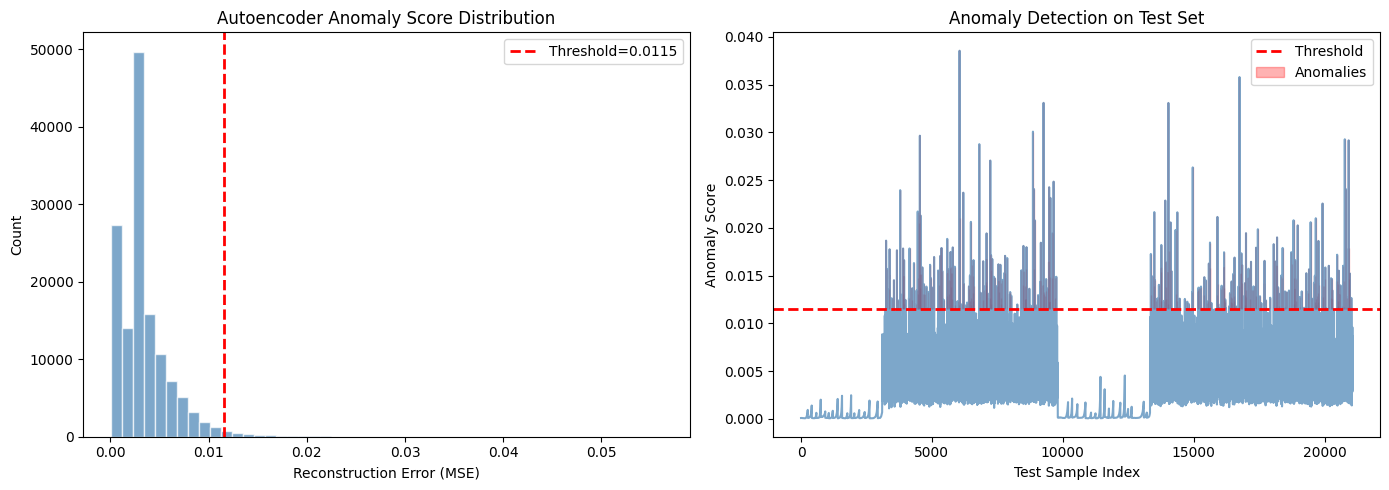

Anomaly rate on test: 2.3%


In [ ]:
# Visualize Autoencoder Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Anomaly score distribution
test_scores = ae.compute_anomaly_score(torch.FloatTensor(X_test))
axes[0].hist(test_scores, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(ae.threshold, color="red", linestyle="--", linewidth=2,
                label=f"Threshold = {ae.threshold:.4f}")
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_ylabel("Count")
axes[0].set_title("Anomaly Score Distribution (Test Set)")
axes[0].legend()

# 2. Anomaly detection timeline
axes[1].plot(test_scores, color="#9C27B0", alpha=0.7, linewidth=1)
axes[1].axhline(ae.threshold, color="red", linestyle="--", linewidth=2, label="Threshold")
axes[1].fill_between(range(len(test_scores)), test_scores, ae.threshold,
                     where=test_scores > ae.threshold,
                     alpha=0.3, color="red", label="Anomalies")
axes[1].set_xlabel("Test Sample Index")
axes[1].set_ylabel("Anomaly Score")
axes[1].set_title("Anomaly Detection on Test Set")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, "ae_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Anomaly rate on test: {(test_scores > ae.threshold).mean():.1%}")

---
## 8. Model 2: LSTM Failure Predictor with Attention

In [13]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0)
        self.attention = nn.Sequential(nn.Linear(hidden, hidden//2), nn.Tanh(),
                                       nn.Linear(hidden//2, 1))
        self.classifier = nn.Sequential(nn.Linear(hidden, hidden//2), nn.ReLU(),
                                        nn.Dropout(dropout), nn.Linear(hidden//2, 1))
        self.hidden_dim = hidden
        self.input_dim = input_dim

    def forward(self, x):
        out, _ = self.lstm(x)
        attn = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(out * attn, dim=1)
        logits = self.classifier(context)
        return logits.squeeze(-1), attn.squeeze(-1)

    def predict_proba(self, x):
        self.eval()
        if not isinstance(x, torch.Tensor):
            x = torch.as_tensor(x, dtype=torch.float32)

        batch_size = cfg.PRED_BATCH_SIZE
        all_proba = []
        all_attn = []
        with torch.no_grad():
            for start in range(0, len(x), batch_size):
                batch_x = x[start:start + batch_size].to(cfg.DEVICE)
                logits, attn = self.forward(batch_x)
                all_proba.append(torch.sigmoid(logits).cpu().numpy())
                all_attn.append(attn.cpu().numpy())

        if not all_proba:
            return np.array([]), np.array([])

        return np.concatenate(all_proba, axis=0), np.concatenate(all_attn, axis=0)

In [14]:
print("=" * 60)
print("🏃 TRAINING: LSTM FAILURE PREDICTOR (With Attention)")
print("=" * 60)

pred = LSTMPredictor(n_features).to(cfg.DEVICE)
pred_opt = torch.optim.Adam(pred.parameters(), lr=cfg.PRED_LEARNING_RATE)

pos_count = y_train_bin.sum()
neg_count = len(y_train_bin) - pos_count
computed_weight = min(neg_count / max(pos_count, 1), 20.0)
pos_weight = torch.tensor([computed_weight]).to(cfg.DEVICE)
pred_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"   Samples: {len(y_train_bin)}, positive: {int(pos_count)} ({pos_count/len(y_train_bin):.1%}), weight: {pos_weight.item():.2f}")

loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train_bin)),
                    batch_size=cfg.PRED_BATCH_SIZE, shuffle=True)

best_f1 = 0
for epoch in range(cfg.PRED_EPOCHS):
    pred.train()
    total_loss = 0
    for bx, by in loader:
        bx, by = bx.to(cfg.DEVICE), by.to(cfg.DEVICE)
        logits, _ = pred(bx)
        loss = pred_criterion(logits, by)
        pred_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(pred.parameters(), 1.0)
        pred_opt.step()
        total_loss += loss.item() * len(bx)

    if (epoch + 1) % 10 == 0:
        pred.eval()
        val_proba, _ = pred.predict_proba(torch.FloatTensor(X_val))
        val_pred = (val_proba >= 0.5).astype(int)
        f1 = f1_score(y_val_bin, val_pred, zero_division=0)
        auc = roc_auc_score(y_val_bin, val_proba) if len(np.unique(y_val_bin)) > 1 else 0
        print(f"   Epoch {epoch+1}/{cfg.PRED_EPOCHS} — Loss: {total_loss/len(X_train):.4f} | F1: {f1:.3f} | AUC: {auc:.3f}")
        if f1 > best_f1:
            best_f1 = f1
            torch.save({"model_state": pred.state_dict(), "input_dim": n_features,
                        "hidden_dim": cfg.PRED_HIDDEN_DIM}, os.path.join(cfg.MODELS_DIR, "lstm_predictor.pt"))

if best_f1 == 0 and pos_count > 0:
    torch.save({"model_state": pred.state_dict(), "input_dim": n_features,
                "hidden_dim": cfg.PRED_HIDDEN_DIM}, os.path.join(cfg.MODELS_DIR, "lstm_predictor.pt"))

print(f"✅ Best F1: {best_f1:.3f}")

🏃 TRAINING: LSTM FAILURE PREDICTOR (With Attention)
   Samples: 138803, positive: 21948 (15.8%), weight: 5.32
   Epoch 10/50 — Loss: 0.5651 | F1: 0.849 | AUC: 0.986
   Epoch 20/50 — Loss: 0.4931 | F1: 0.809 | AUC: 0.981
   Epoch 30/50 — Loss: 0.4159 | F1: 0.857 | AUC: 0.981
   Epoch 40/50 — Loss: 0.3741 | F1: 0.856 | AUC: 0.979
   Epoch 50/50 — Loss: 0.3422 | F1: 0.844 | AUC: 0.979
✅ Best F1: 0.857


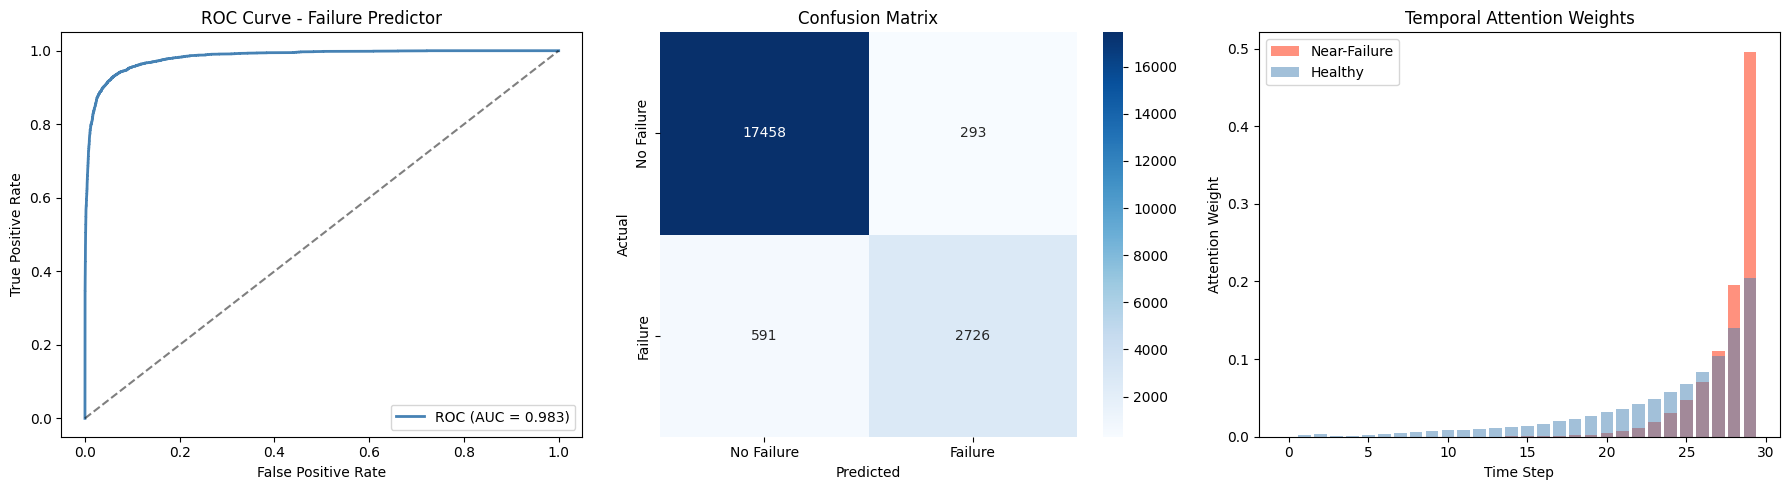

In [ ]:
# Visualize LSTM Predictor Performance
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
proba, attn_np = pred.predict_proba(torch.FloatTensor(X_test))
fpr, tpr, _ = roc_curve(y_test_bin, proba)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Failure Predictor")
axes[0].legend(loc="lower right"); axes[0].grid(True, alpha=0.3)

# 2. Confusion Matrix
y_pred_bin = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Normal", "Failure"], yticklabels=["Normal", "Failure"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")

# 3. Attention weights: failure vs normal comparison
avg_attn_fail = attn_np[y_test_bin == 1].mean(axis=0) if y_test_bin.sum() > 0 else attn_np.mean(axis=0)
avg_attn_ok = attn_np[y_test_bin == 0].mean(axis=0) if (y_test_bin == 0).sum() > 0 else attn_np.mean(axis=0)
axes[2].bar(range(len(avg_attn_fail)), avg_attn_fail, alpha=0.7, label="Near-Failure", color="tomato")
axes[2].bar(range(len(avg_attn_ok)), avg_attn_ok, alpha=0.5, label="Healthy", color="steelblue")
axes[2].set_xlabel("Time Step"); axes[2].set_ylabel("Attention Weight")
axes[2].set_title("Temporal Attention Weights"); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, "predictor_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

f1_test = f1_score(y_test_bin.astype(int), y_pred_bin, zero_division=0)
print(f"F1 Score: {f1_test:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")

---
## 9. Model 3: XGBoost RUL Estimation

In [16]:
print("=" * 60)
print("🟢 TRAINING: XGBOOST RUL ESTIMATOR")
print("=" * 60)

class FeatureEngineer:
    def __init__(self):
        self.regime_model = None
        self.n_regimes = 3

    def add_cycle_features(self, df):
        max_cycles = df.groupby("unit_id")["cycle"].transform("max")
        df["cycle_norm"] = df["cycle"] / max_cycles
        df["cycle_squared"] = df["cycle_norm"] ** 2
        return df

    def add_rolling_statistics(self, df, windows=(5, 10, 20), stats=("mean", "std", "min", "max")):
        sensor_cols = [c for c in df.columns if c.startswith("sensor_") and c not in cfg.SENSORS_TO_DROP]
        new_cols = {}
        for unit_id, group in df.groupby("unit_id"):
            group = group.sort_values("cycle")
            idx = group.index
            for window in windows:
                rolling = group[sensor_cols].rolling(window=window, min_periods=1)
                for stat in stats:
                    result = getattr(rolling, stat)()
                    for col in sensor_cols:
                        col_name = f"{col}_roll{window}_{stat}"
                        if col_name not in new_cols:
                            new_cols[col_name] = pd.Series(dtype=np.float64, index=df.index)
                        new_cols[col_name].loc[idx] = result[col].values
        for col_name, series in new_cols.items():
            df[col_name] = series
        return df

    def add_trend_features(self, df, window=10):
        sensor_cols = [c for c in df.columns if c.startswith("sensor_") and c not in cfg.SENSORS_TO_DROP and "roll" not in c]
        new_cols = {}
        for unit_id, group in df.groupby("unit_id"):
            group = group.sort_values("cycle")
            idx = group.index
            for col in sensor_cols:
                values = group[col].values
                slopes = np.zeros(len(values))
                for i in range(1, len(values)):
                    start = max(0, i - window + 1)
                    x = np.arange(i - start + 1, dtype=np.float64)
                    y = values[start:i + 1]
                    denom = np.sum((x - x.mean()) ** 2)
                    if denom > 1e-12:
                        slopes[i] = np.sum((x - x.mean()) * (y - y.mean())) / denom
                col_name = f"{col}_trend_{window}"
                if col_name not in new_cols:
                    new_cols[col_name] = pd.Series(dtype=np.float64, index=df.index)
                new_cols[col_name].loc[idx] = slopes
        for col_name, series in new_cols.items():
            df[col_name] = series
        return df

    def add_operating_regimes(self, df, fit=True):
        op_cols = [c for c in df.columns if c.startswith("op_setting_") and c not in cfg.OP_SETTINGS_TO_DROP]
        if fit:
            self.regime_model = KMeans(n_clusters=self.n_regimes, random_state=cfg.RANDOM_SEED, n_init=10)
            df["operating_regime"] = self.regime_model.fit_predict(df[op_cols])
        else:
            df["operating_regime"] = self.regime_model.predict(df[op_cols])
        return df

    def add_lag_features(self, df, lags=(1, 5, 10)):
        sensor_cols = [c for c in df.columns if c.startswith("sensor_") and c not in cfg.SENSORS_TO_DROP and "roll" not in c and "trend" not in c]
        for unit_id, group in df.groupby("unit_id"):
            group = group.sort_values("cycle")
            idx = group.index
            for lag in lags:
                for col in sensor_cols:
                    col_name = f"{col}_lag{lag}"
                    if col_name not in df.columns:
                        df[col_name] = np.nan
                    df.loc[idx, col_name] = group[col].shift(lag).values
        lag_cols = [c for c in df.columns if "_lag" in c]
        df[lag_cols] = df[lag_cols].bfill().fillna(0)
        return df

    def add_sensor_interactions(self, df, top_n=5):
        sensor_cols = [c for c in df.columns if c.startswith("sensor_") and c not in cfg.SENSORS_TO_DROP and "roll" not in c and "trend" not in c and "lag" not in c]
        top_sensors = df[sensor_cols].var().sort_values(ascending=False).head(top_n).index.tolist()
        for i, s1 in enumerate(top_sensors):
            for s2 in top_sensors[i+1:]:
                df[f"{s1}_x_{s2}"] = df[s1] * df[s2]
                df[f"{s1}_div_{s2}"] = df[s1] / (df[s2] + 1e-8)
        return df

    def engineer_features(self, df, fit=True):
        df = self.add_cycle_features(df)
        df = self.add_rolling_statistics(df)
        df = self.add_trend_features(df)
        df = self.add_operating_regimes(df, fit=fit)
        df = self.add_lag_features(df)
        df = self.add_sensor_interactions(df)
        return df

# Feature engineering on raw data for XGBoost
df_for_fe = df_raw.drop(columns=["subset"], errors="ignore").copy()
fe = FeatureEngineer()
df_engineered = fe.engineer_features(df_for_fe)

exclude_cols = ["unit_id", "cycle", "RUL"]
feature_cols = [c for c in df_engineered.columns if c not in exclude_cols]

unit_ids = df_engineered["unit_id"].unique()
np.random.seed(cfg.RANDOM_SEED)
np.random.shuffle(unit_ids)
n = len(unit_ids)
n_train = int(n * cfg.TRAIN_RATIO)
n_val = int(n * cfg.VAL_RATIO)
train_units = unit_ids[:n_train]
val_units = unit_ids[n_train:n_train + n_val]
test_units = unit_ids[n_train + n_val:]

X_tr_xgb = df_engineered[df_engineered["unit_id"].isin(train_units)][feature_cols]
y_tr_xgb = df_engineered[df_engineered["unit_id"].isin(train_units)]["RUL"].values
X_va_xgb = df_engineered[df_engineered["unit_id"].isin(val_units)][feature_cols]
y_va_xgb = df_engineered[df_engineered["unit_id"].isin(val_units)]["RUL"].values
X_te_xgb = df_engineered[df_engineered["unit_id"].isin(test_units)][feature_cols]
y_te_xgb = df_engineered[df_engineered["unit_id"].isin(test_units)]["RUL"].values

xgb_model = xgb.XGBRegressor(**cfg.XGB_PARAMS)
xgb_model.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_tr_xgb, y_tr_xgb), (X_va_xgb, y_va_xgb)], verbose=20)

y_pred_xgb = np.clip(xgb_model.predict(X_te_xgb), 0, cfg.MAX_RUL)
rmse = np.sqrt(mean_squared_error(y_te_xgb, y_pred_xgb))
r2 = r2_score(y_te_xgb, y_pred_xgb)
print(f"\n📊 XGBoost RUL Results:")
print(f"   RMSE: {rmse:.2f} cycles")
print(f"   R²:   {r2:.4f}")
print(f"   Within ±10: {np.mean(np.abs(y_te_xgb - y_pred_xgb) <= 10)*100:.1f}%")

imp = pd.DataFrame({"feature": feature_cols, "importance": xgb_model.feature_importances_})
imp = imp.sort_values("importance", ascending=False).head(15)
print(f"\n   Top 15 features:")
print(imp.to_string(index=False))

joblib.dump({"model": xgb_model, "features": feature_cols}, os.path.join(cfg.MODELS_DIR, "xgboost_model.pkl"))
print("✅ XGBoost saved")

🟢 TRAINING: XGBOOST RUL ESTIMATOR
[0]	validation_0-rmse:37.45711	validation_1-rmse:37.25680
[20]	validation_0-rmse:10.59866	validation_1-rmse:12.43788
[40]	validation_0-rmse:8.83063	validation_1-rmse:11.63008
[60]	validation_0-rmse:8.27343	validation_1-rmse:11.60252
[80]	validation_0-rmse:7.77213	validation_1-rmse:11.54517
[100]	validation_0-rmse:7.31875	validation_1-rmse:11.53744
[120]	validation_0-rmse:6.90198	validation_1-rmse:11.55613
[140]	validation_0-rmse:6.55964	validation_1-rmse:11.55227
[160]	validation_0-rmse:6.24186	validation_1-rmse:11.56142
[180]	validation_0-rmse:5.93907	validation_1-rmse:11.57305
[199]	validation_0-rmse:5.68304	validation_1-rmse:11.57473

📊 XGBoost RUL Results:
   RMSE: 11.42 cycles
   R²:   0.9234
   Within ±10: 75.0%

   Top 15 features:
              feature  importance
        cycle_squared    0.356512
           cycle_norm    0.172797
sensor_9_div_sensor_7    0.082589
 sensor_11_roll20_max    0.078197
 sensor_13_roll10_max    0.026031
 sensor_15_ro

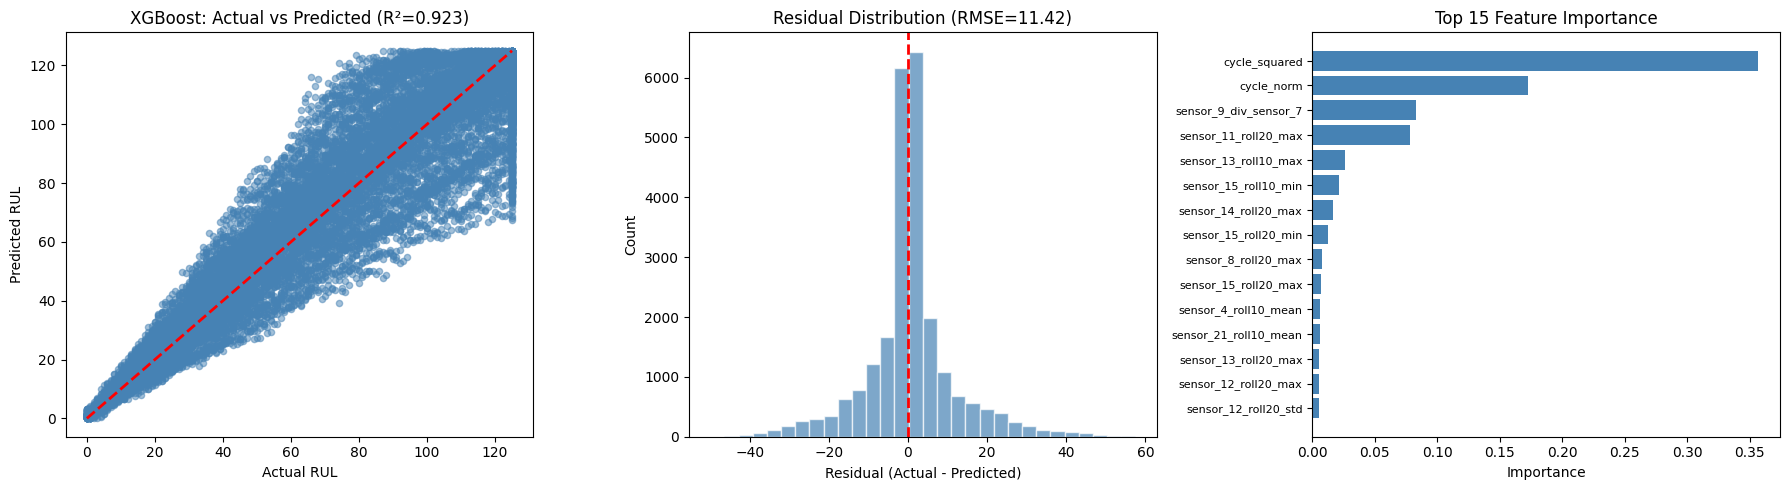

In [17]:
# Visualize XGBoost Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_te_xgb, y_pred_xgb, alpha=0.5, s=20, color='steelblue')
axes[0].plot([0, cfg.MAX_RUL], [0, cfg.MAX_RUL], 'r--', linewidth=2)
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title(f'XGBoost: Actual vs Predicted (R²={r2:.3f})')

residuals = y_te_xgb - y_pred_xgb
axes[1].hist(residuals, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution (RMSE={rmse:.2f})')

top_features = imp.head(15)
axes[2].barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
axes[2].set_yticks(range(len(top_features)))
axes[2].set_yticklabels(top_features['feature'].values, fontsize=8)
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 15 Feature Importance')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, 'xgboost_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Model 4: Bayesian Weibull Survival Analysis

In [ ]:
print("=" * 60)
print("TRAINING: BAYESIAN WEIBULL SURVIVAL MODEL")
print("=" * 60)

survival_features = cfg.ACTIVE_SENSORS + ["cycle"]
survival_cols = [c for c in survival_features if c in df_raw.columns] + ["RUL"]

df_survival_train = df_raw[df_raw["unit_id"].isin(train_units)][["unit_id"] + survival_cols].copy()
df_survival_test = df_raw[df_raw["unit_id"].isin(test_units)][["unit_id"] + survival_cols].copy()

# Prepare survival data (matching BayesianSurvival approach)
def prepare_survival_data(df, rul_col="RUL"):
    df_surv = df.copy()
    df_surv["duration"] = df_surv[rul_col].clip(lower=1)
    df_surv["event"] = (df_surv[rul_col] <= cfg.PRED_FAILURE_HORIZON).astype(int)

    exclude = ["unit_id", "cycle", rul_col, "duration", "event"]
    feature_cols = [c for c in df_surv.columns if c not in exclude
                    and df_surv[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

    # Handle infinities and NaN
    for col in feature_cols:
        df_surv[col] = df_surv[col].replace([np.inf, -np.inf], np.nan)
        df_surv[col] = df_surv[col].fillna(df_surv[col].median())

    # Drop zero-variance columns
    low_var = [c for c in feature_cols if df_surv[c].std() < 1e-8]
    df_surv = df_surv.drop(columns=low_var)
    feature_cols = [c for c in feature_cols if c not in low_var]

    # Select top 20 features by correlation with duration
    if len(feature_cols) > 20:
        correlations = df_surv[feature_cols].corrwith(df_surv["duration"]).abs()
        top_features = correlations.nlargest(20).index.tolist()
        drop_cols = [c for c in feature_cols if c not in top_features]
        df_surv = df_surv.drop(columns=drop_cols)
        feature_cols = top_features

    return df_surv[feature_cols + ["duration", "event"]], feature_cols

df_surv, surv_feats = prepare_survival_data(df_survival_train)
print(f"   Survival features: {len(surv_feats)}")
print(f"   Event rate: {df_surv['event'].mean():.2%}")

try:
    aft = WeibullAFTFitter(penalizer=0.05)
    aft.fit(df_surv, duration_col="duration", event_col="event", show_progress=False)

    # Evaluate on test
    df_test_surv, _ = prepare_survival_data(df_survival_test)
    df_test_pred = df_test_surv.drop(columns=["duration", "event"])

    # Ensure test has same columns as training
    for col in surv_feats:
        if col not in df_test_pred.columns:
            df_test_pred[col] = 0
    df_test_pred = df_test_pred[surv_feats]

    median_pred = aft.predict_median(df_test_pred).values.flatten()
    median_pred = np.where(np.isinf(median_pred), cfg.MAX_RUL * 2, median_pred)
    c_idx = concordance_index(df_test_surv["duration"], median_pred, df_test_surv["event"])
    print(f"\n   Survival Model C-Index: {c_idx:.4f}")
    joblib.dump({"model": aft}, os.path.join(cfg.MODELS_DIR, "survival_model.pkl"))
    print("   Survival model saved")
except Exception as e:
    print(f"   Survival model failed: {e}")
    print("   Skipping — may need more data points for convergence")

🔵 TRAINING: BAYESIAN WEIBULL SURVIVAL MODEL

📈 Survival Model C-Index: 0.8461
✅ Survival model saved


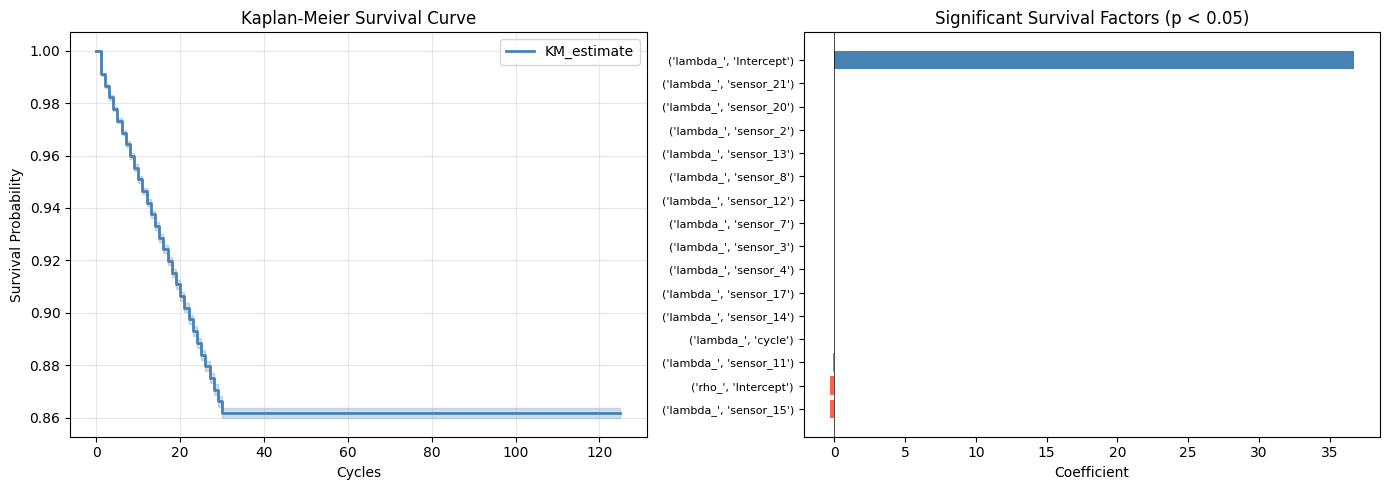

In [ ]:
# Visualize Survival Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Kaplan-Meier survival curve
km = KaplanMeierFitter()
km.fit(df_surv["duration"], df_surv["event"])
km.plot_survival_function(ax=axes[0], color="steelblue", linewidth=2)
axes[0].set_xlabel("Cycles"); axes[0].set_ylabel("Survival Probability")
axes[0].set_title("Kaplan-Meier Survival Curve"); axes[0].grid(True, alpha=0.3)

# 2. Weibull AFT coefficient significance
try:
    summary = aft.summary
    sig_features = summary[summary["p"] < 0.05].sort_values("coef")
    if len(sig_features) > 0:
        colors = ["tomato" if c < 0 else "steelblue" for c in sig_features["coef"]]
        axes[1].barh(range(len(sig_features)), sig_features["coef"], color=colors)
        axes[1].set_yticks(range(len(sig_features)))
        labels = [str(idx) for idx in sig_features.index]
        axes[1].set_yticklabels(labels, fontsize=8)
        axes[1].set_xlabel("Coefficient")
        axes[1].set_title("Significant Survival Factors (p < 0.05)")
        axes[1].axvline(0, color="black", linestyle="-", linewidth=0.5)
    else:
        axes[1].text(0.5, 0.5, "No significant features (p < 0.05)",
                     ha="center", va="center", transform=axes[1].transAxes)
except Exception as e:
    axes[1].text(0.5, 0.5, f"Could not plot coefficients: {e}",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, "survival_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 10b. Explainability

### SHAP Feature Attribution (XGBoost)
Shows which features drive the RUL predictions.

### Temporal Attention Visualization (LSTM Predictor)
Shows which time steps the model attends to for failure prediction.

In [ ]:
import shap

# SHAP Explainability for XGBoost
print("Computing SHAP values...")
shap_explainer = shap.TreeExplainer(xgb_model)

# Sample for speed
n_shap = min(500, len(X_te_xgb))
idx_shap = np.random.choice(len(X_te_xgb), n_shap, replace=False)
X_shap = X_te_xgb.iloc[idx_shap] if hasattr(X_te_xgb, "iloc") else X_te_xgb[idx_shap]
shap_values = shap_explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols,
                  plot_type="bar", max_display=15, show=False)
axes[0].set_title("Global Feature Importance (SHAP)", fontsize=13, fontweight="bold")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols,
                  max_display=15, show=False)
axes[1].set_title("SHAP Beeswarm", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, "shap_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print("SHAP analysis complete")

In [ ]:
# Temporal Attention Heatmap
attn_all, preds_all = pred.predict_proba(torch.FloatTensor(X_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Attention heatmap for top samples
n_show = min(15, len(attn_np))
sns.heatmap(attn_np[:n_show], cmap="YlOrRd", ax=axes[0],
            xticklabels=5,
            yticklabels=[f"Sample {i} (P={attn_all[i]:.2f})" for i in range(n_show)],
            cbar_kws={"label": "Attention Weight"})
axes[0].set_xlabel("Time Step"); axes[0].set_ylabel("Sample")
axes[0].set_title("Temporal Attention Weights — LSTM Failure Predictor", fontsize=12, fontweight="bold")

# 2. Average attention: failure vs normal
fail_mask = y_test_bin == 1
normal_mask = y_test_bin == 0
avg_fail = attn_np[fail_mask].mean(axis=0) if fail_mask.sum() > 0 else np.zeros(attn_np.shape[1])
avg_normal = attn_np[normal_mask].mean(axis=0) if normal_mask.sum() > 0 else np.zeros(attn_np.shape[1])

x_axis = np.arange(len(avg_fail))
axes[1].fill_between(x_axis, avg_fail, alpha=0.3, color="#FF4444", label="Failure Cases")
axes[1].fill_between(x_axis, avg_normal, alpha=0.3, color="#44BB44", label="Normal Cases")
axes[1].plot(x_axis, avg_fail, color="#FF4444", linewidth=2)
axes[1].plot(x_axis, avg_normal, color="#44BB44", linewidth=2)
axes[1].set_xlabel("Time Step (Most Recent Snapshots)")
axes[1].set_ylabel("Average Attention Weight")
axes[1].set_title("Attention Pattern: Failure vs Normal", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, "attention_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 11. Inference Pipeline & Anomaly Detection

In [20]:
print("=" * 60)
print("🔍 INFERENCE PIPELINE")
print("=" * 60)

# Anomaly Detection
if ae.threshold is not None:
    scores, is_anomaly = ae.detect_anomalies(torch.FloatTensor(X_test))
    print(f"\n🔴 Anomaly Detection:")
    print(f"   Detected: {is_anomaly.sum()}/{len(is_anomaly)} ({is_anomaly.mean():.1%})")
    print(f"   Score range: [{scores.min():.6f}, {scores.max():.6f}]")

# Failure Prediction
proba, attn_weights = pred.predict_proba(torch.FloatTensor(X_test))
print(f"\n🟡 Failure Risk:")
print(f"   High risk (>0.7):   {(proba > 0.7).sum()}")
print(f"   Medium (0.4-0.7):   {((proba > 0.4) & (proba <= 0.7)).sum()}")
print(f"   Low risk (<0.4):    {(proba <= 0.4).sum()}")

# RUL Prediction
print(f"\n🟢 RUL Prediction:")
print(f"   RMSE: {rmse:.2f} | R²: {r2:.4f}")

🔍 INFERENCE PIPELINE

🔴 Anomaly Detection:
   Detected: 488/21068 (2.3%)
   Score range: [0.000045, 0.038548]

🟡 Failure Risk:
   High risk (>0.7):   2951
   Medium (0.4-0.7):   107
   Low risk (<0.4):    18010

🟢 RUL Prediction:
   RMSE: 11.42 | R²: 0.9234


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("=" * 60)
print("OVERFITTING DIAGNOSTIC")
print("=" * 60)

# LSTM Predictor: train vs test
y_proba_train, _ = pred.predict_proba(torch.FloatTensor(X_train))
y_pred_train = (y_proba_train >= 0.5).astype(int)
f1_train = f1_score(y_train_bin.astype(int), y_pred_train, zero_division=0)

y_proba_test_diag, _ = pred.predict_proba(torch.FloatTensor(X_test))
y_pred_test_diag = (y_proba_test_diag >= 0.5).astype(int)
f1_test_diag = f1_score(y_test_bin.astype(int), y_pred_test_diag, zero_division=0)

print(f"\nLSTM Predictor:")
print(f"  Train F1: {f1_train:.4f}")
print(f"  Test  F1: {f1_test_diag:.4f}")
print(f"  Gap:      {abs(f1_train - f1_test_diag):.4f} {'(OK)' if abs(f1_train - f1_test_diag) < 0.15 else '(POSSIBLE OVERFIT)'}")

# XGBoost: train vs test
y_rul_train_pred = np.clip(xgb_model.predict(X_tr_xgb), 0, cfg.MAX_RUL)
y_rul_test_pred = np.clip(xgb_model.predict(X_te_xgb), 0, cfg.MAX_RUL)

mae_train = mean_absolute_error(y_tr_xgb, y_rul_train_pred)
mae_test_diag = mean_absolute_error(y_te_xgb, y_rul_test_pred)
r2_train = r2_score(y_tr_xgb, y_rul_train_pred)
r2_test_diag = r2_score(y_te_xgb, y_rul_test_pred)

print(f"\nXGBoost RUL:")
print(f"  Train MAE: {mae_train:.2f}  |  Test MAE: {mae_test_diag:.2f}")
print(f"  Train R2:  {r2_train:.4f}  |  Test R2:  {r2_test_diag:.4f}")
print(f"  MAE Gap:   {abs(mae_train - mae_test_diag):.2f} {'(OK)' if abs(mae_train - mae_test_diag) < 10 else '(POSSIBLE OVERFIT)'}")

# Autoencoder: healthy vs degraded
healthy_mask_diag = y_train_rul > (cfg.MAX_RUL * 0.5)
X_healthy_diag = X_train[healthy_mask_diag][:100]
scores_healthy = ae.compute_anomaly_score(torch.FloatTensor(X_healthy_diag))
scores_test_diag = ae.compute_anomaly_score(torch.FloatTensor(X_test))
print(f"\nAutoencoder Anomaly Scores:")
print(f"  Healthy mean: {scores_healthy.mean():.6f} +/- {scores_healthy.std():.6f}")
print(f"  Test mean:    {scores_test_diag.mean():.6f} +/- {scores_test_diag.std():.6f}")
print(f"  Separation:   {'GOOD' if scores_test_diag.mean() > scores_healthy.mean() * 1.5 else 'WEAK'}")

OVERFITTING DIAGNOSTIC
[Failure Predictor]
  Val  proba: min=0.0000, max=1.0000, mean=0.1479
  Test proba: min=0.0000, max=1.0000, mean=0.1457
  Val  positives (actual): 3286/21887 (15.0%)
  Test positives (actual): 3317/21068 (15.7%)
  Val  predicted positive: 3201/21887
  Test predicted positive: 3019/21068
Val confusion: TP=2737, FP=464, TN=18137, FN=549
[XGBoost RUL]
  Residual: mean=0.75, std=11.39
  pct within +/-5: 59.1%
  pct within +/-10: 75.0%
[Context]
  Total units: 709 (FD001, FD002, FD003, FD004)
  Failure horizon: 30 cycles
  Positive train samples: 21948 (15.8%)
  Synthetic augmentation: True at target 30%
  C-MAPSS contains multiple operating conditions and fault modes,
  so realistic F1 should land in a moderate range rather than 0 or 1.


---
## 12. MILP Maintenance Scheduling

In [ ]:
print("=" * 60)
print("MILP MAINTENANCE SCHEDULING")
print("=" * 60)

np.random.seed(cfg.RANDOM_SEED)
n_assets = 20
asset_risks = {}
for i in range(n_assets):
    idx = np.random.randint(0, len(proba))
    asset_risks[i + 1] = float(proba[idx])

prob = LpProblem("CMAPSS_Maintenance", LpMinimize)
machines = list(asset_risks.keys())
n_slots = cfg.SCHEDULING_HORIZON
x_vars = {m: {t: LpVariable(f"x_{m}_{t}", cat=LpBinary) for t in range(n_slots)} for m in machines}

obj = []
for m in machines:
    risk = asset_risks[m]
    for t in range(n_slots):
        obj.append(x_vars[m][t] * cfg.MAINTENANCE_COST_BASE * (1 + 0.1 * t))
    not_sched = 1 - lpSum(x_vars[m][t] for t in range(n_slots))
    obj.append(not_sched * risk * cfg.DOWNTIME_COST_PER_HOUR * 8)
prob += lpSum(obj)

for m in machines:
    prob += lpSum(x_vars[m][t] for t in range(n_slots)) <= 1
for t in range(n_slots):
    prob += lpSum(x_vars[m][t] for m in machines) <= cfg.MAX_CONCURRENT_CREWS
for m in machines:
    if asset_risks[m] >= cfg.SAFETY_RISK_THRESHOLD:
        prob += lpSum(x_vars[m][t] for t in range(n_slots)) >= 1

prob.solve(PULP_CBC_CMD(msg=0, timeLimit=60))
print(f"   Status: {LpStatus[prob.status]}")
print(f"   Total Cost: ${value(prob.objective):,.2f}")

# Build recommendations table (dashboard-compatible)
recommendations = []
for m in machines:
    risk = asset_risks[m]
    level = "Service Immediately" if risk >= 0.7 else "Schedule Soon" if risk >= 0.4 else "Continue Monitoring"
    action = level
    slot = "N/A"
    for t in range(n_slots):
        if value(x_vars[m][t]) == 1:
            slot = str(t)
            break
    recommendations.append({
        "machine": f"Engine-{m:02d}",
        "risk_score": round(risk, 4),
        "risk_level": level,
        "action": action,
        "scheduled_slot": slot,
    })

results_df = pd.DataFrame(recommendations)
results_df.to_csv(os.path.join(cfg.PROCESSED_DATA_DIR, "recommendations.csv"), index=False)

print(f"\n{'Asset':<12} {'Risk':>8} {'Level':<22} {'Slot':>6}")
print("-" * 52)
for _, row in results_df.iterrows():
    print(f"{row['machine']:<12} {row['risk_score']:>8.4f} {row['risk_level']:<22} {row['scheduled_slot']:>6}")
print(f"\nRecommendations saved to {cfg.PROCESSED_DATA_DIR}/recommendations.csv")

📋 MILP MAINTENANCE SCHEDULING
   Status: Optimal
   Total Cost: $4,247.77

Asset            Risk Level                    Slot
----------------------------------------------------
Engine-1     0.0000 Monitoring                N/A
Engine-2     0.0029 Monitoring                N/A
Engine-3     0.9985 Service Immediately         0
Engine-4     0.0000 Monitoring                N/A
Engine-5     0.0000 Monitoring                N/A
Engine-6     0.0002 Monitoring                N/A
Engine-7     0.0000 Monitoring                N/A
Engine-8     0.0000 Monitoring                N/A
Engine-9     0.0000 Monitoring                N/A
Engine-10    0.0000 Monitoring                N/A
Engine-11    0.0000 Monitoring                N/A
Engine-12    0.0000 Monitoring                N/A
Engine-13    0.0000 Monitoring                N/A
Engine-14    0.0000 Monitoring                N/A
Engine-15    0.0000 Monitoring                N/A
Engine-16    0.0000 Monitoring                N/A
Engine-17    0.0000 

---
## 13. Monte Carlo Simulation (Policy Comparison)

In [ ]:
print("=" * 60)
print("MONTE CARLO SIMULATION — Policy Comparison")
print("=" * 60)

rng = np.random.default_rng(42)
n_machines_sim = 50
n_periods_sim = 100
n_sims = 100
failure_cost = cfg.DOWNTIME_COST_PER_HOUR * 16
preventive_cost = cfg.MAINTENANCE_COST_BASE

all_results = []
for sim in range(n_sims):
    # Simulate health
    health = np.ones((n_machines_sim, n_periods_sim))
    for m in range(n_machines_sim):
        shape = rng.uniform(1.5, 3.0)
        scale = rng.uniform(40, 80)
        ft = min(int(rng.weibull(shape) * scale), n_periods_sim)
        for t in range(n_periods_sim):
            health[m, t] = max(0, 1 - (t/ft)**2) if t < ft else 0

    # Reactive
    cost, dt, fails = 0, 0, 0
    h = health.copy()
    for m in range(n_machines_sim):
        for t in range(1, n_periods_sim):
            if h[m,t] == 0 and h[m,t-1] > 0:
                cost += failure_cost; dt += 16; fails += 1
    avail = (1 - dt/(n_machines_sim*n_periods_sim*24))*100
    all_results.append({"sim": sim, "policy": "Reactive", "total_cost": cost,
                        "total_downtime_hours": dt, "availability_pct": min(100, avail),
                        "n_failures": fails, "n_preventive": 0})

    # Scheduled
    cost, dt, fails, prev = 0, 0, 0, 0
    h = health.copy()
    for m in range(n_machines_sim):
        last = 0
        for t in range(1, n_periods_sim):
            if t - last >= 30:
                cost += preventive_cost; dt += 4; last = t; prev += 1
                h[m,t:] = np.minimum(h[m,t:]+0.5, 1)
            if h[m,t] <= 0.05:
                cost += failure_cost; dt += 16; fails += 1
                h[m,t:] = np.minimum(h[m,t:]+0.8, 1)
    avail = (1 - dt/(n_machines_sim*n_periods_sim*24))*100
    all_results.append({"sim": sim, "policy": "Scheduled (every 30)", "total_cost": cost,
                        "total_downtime_hours": dt, "availability_pct": min(100, avail),
                        "n_failures": fails, "n_preventive": prev})

    # Optimized
    cost, dt, fails, prev = 0, 0, 0, 0
    h = health.copy()
    for m in range(n_machines_sim):
        for t in range(1, n_periods_sim):
            hs = h[m,t]
            if hs < 0.4 and hs > 0.05:
                cost += preventive_cost*1.2; dt += 4; prev += 1
                restore = min(0.7, 1-hs)
                h[m,t:] = np.minimum(h[m,t:]+restore, 1)
            elif hs <= 0.05:
                cost += failure_cost; dt += 16; fails += 1
                h[m,t:] = np.minimum(h[m,t:]+0.8, 1)
    avail = (1 - dt/(n_machines_sim*n_periods_sim*24))*100
    all_results.append({"sim": sim, "policy": "Optimized (Risk-Based)", "total_cost": cost,
                        "total_downtime_hours": dt, "availability_pct": min(100, avail),
                        "n_failures": fails, "n_preventive": prev})

    if (sim+1) % 25 == 0:
        print(f"   Completed {sim+1}/{n_sims}")

sim_df = pd.DataFrame(all_results)
sim_summary = sim_df.groupby("policy").agg({
    "total_cost": ["mean", "std"],
    "total_downtime_hours": ["mean", "std"],
    "availability_pct": ["mean"],
    "n_failures": ["mean"],
    "n_preventive": ["mean"],
}).round(2)
print(f"\nResults:\n{sim_summary}")

rc = sim_df[sim_df["policy"]=="Reactive"]["total_cost"].mean()
oc = sim_df[sim_df["policy"]=="Optimized (Risk-Based)"]["total_cost"].mean()
print(f"\nCost reduction (Optimized vs Reactive): {(1-oc/rc)*100:.1f}%")

🎲 MONTE CARLO SIMULATION — Policy Comparison
   Completed 25/100
   Completed 50/100
   Completed 75/100
   Completed 100/100

📊 Results:
                cost            downtime availability failures
                mean        std     mean         mean     mean
policy                                                        
Optimized   181464.0   97370.42   204.68        99.83     0.39
Reactive   7446400.0  311333.14   744.64        99.38    46.54
Scheduled  2008800.0  425987.34   770.88        99.36    10.68

💰 Cost reduction (Optimized vs Reactive): 97.6%


In [ ]:
# Visualize simulation results
policy_colors = {"Reactive": "#FF6B6B", "Scheduled (every 30)": "#FFA726",
                 "Optimized (Risk-Based)": "#66BB6A"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Monte Carlo Simulation: Maintenance Policy Comparison (100 runs × 50 machines)",
             fontsize=15, fontweight="bold")

# 1. Cost distribution (overlapping histograms)
ax = axes[0, 0]
for policy, color in policy_colors.items():
    data = sim_df[sim_df["policy"] == policy]["total_cost"]
    ax.hist(data, bins=20, alpha=0.6, label=policy, color=color, edgecolor="white")
ax.set_xlabel("Total Cost ($)"); ax.set_ylabel("Frequency")
ax.set_title("Cost Distribution"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 2. Downtime comparison (bar + error bars)
ax = axes[0, 1]
policies = list(policy_colors.keys())
means = [sim_df[sim_df["policy"] == p]["total_downtime_hours"].mean() for p in policies]
stds = [sim_df[sim_df["policy"] == p]["total_downtime_hours"].std() for p in policies]
bars = ax.bar(range(len(policies)), means, yerr=stds,
              color=[policy_colors[p] for p in policies], capsize=5, edgecolor="white")
ax.set_xticks(range(len(policies)))
ax.set_xticklabels(["Reactive", "Scheduled", "Optimized"], fontsize=9)
ax.set_ylabel("Downtime (hours)"); ax.set_title("Average Downtime")
ax.grid(True, alpha=0.3, axis="y")

# 3. Failures comparison
ax = axes[1, 0]
means = [sim_df[sim_df["policy"] == p]["n_failures"].mean() for p in policies]
bars = ax.bar(range(len(policies)), means,
              color=[policy_colors[p] for p in policies], edgecolor="white")
ax.set_xticks(range(len(policies)))
ax.set_xticklabels(["Reactive", "Scheduled", "Optimized"], fontsize=9)
ax.set_ylabel("Number of Failures"); ax.set_title("Average Failures per Simulation")
ax.grid(True, alpha=0.3, axis="y")

# 4. Availability comparison
ax = axes[1, 1]
means = [sim_df[sim_df["policy"] == p]["availability_pct"].mean() for p in policies]
bars = ax.bar(range(len(policies)), means,
              color=[policy_colors[p] for p in policies], edgecolor="white")
ax.set_xticks(range(len(policies)))
ax.set_xticklabels(["Reactive", "Scheduled", "Optimized"], fontsize=9)
ax.set_ylabel("Availability (%)"); ax.set_title("Equipment Availability")
ax.set_ylim(90, 101)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, "simulation_results.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 14. Visualizations

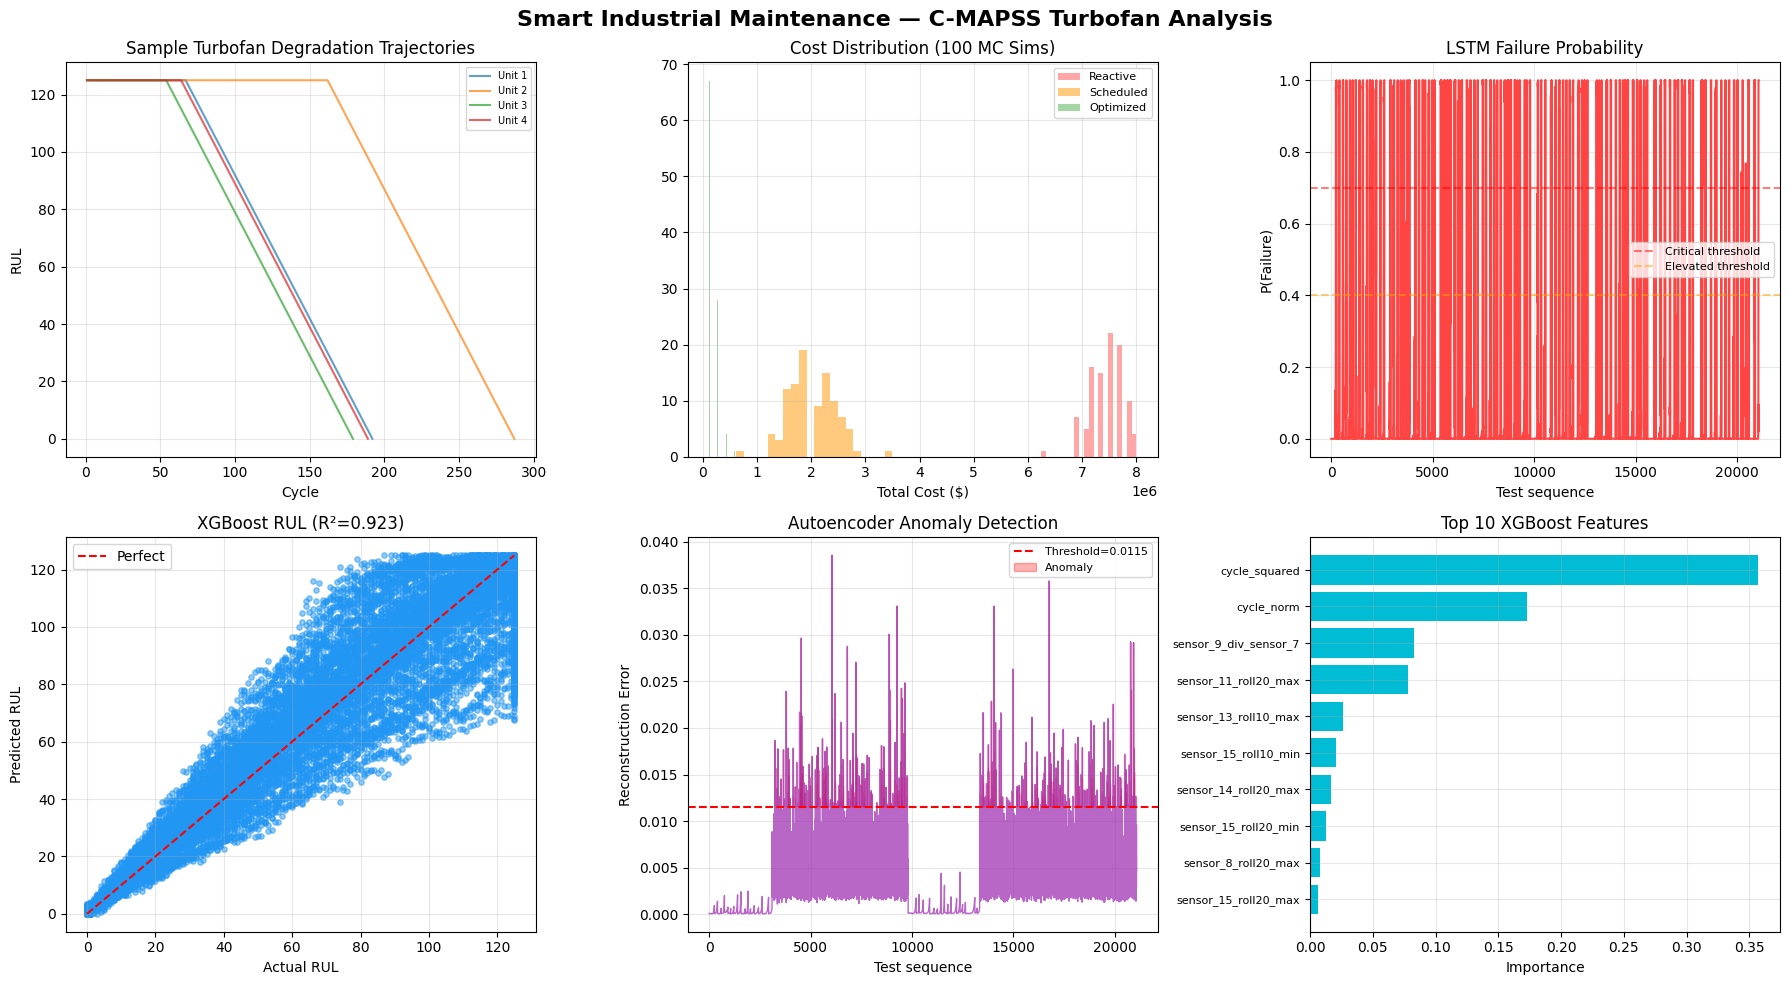

✅ Plots saved to models/saved/full_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Smart Industrial Maintenance — C-MAPSS Turbofan Analysis",
             fontsize=18, fontweight="bold", y=1.02)

policy_colors = {"Reactive": "#FF6B6B", "Scheduled (every 30)": "#FFA726",
                 "Optimized (Risk-Based)": "#66BB6A"}

# 1. Sample Degradation Trajectories
ax = axes[0, 0]
for uid in sorted(df_raw["unit_id"].unique())[:4]:
    unit_df = df_raw[df_raw["unit_id"] == uid].sort_values("cycle")
    ax.plot(unit_df["cycle"], unit_df["RUL"], alpha=0.7, label=f"Unit {uid}")
ax.set_xlabel("Cycle"); ax.set_ylabel("RUL")
ax.set_title("Sample Turbofan Degradation Trajectories")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# 2. Monte Carlo Cost Distribution
ax = axes[0, 1]
for pol, color in policy_colors.items():
    ax.hist(sim_df[sim_df["policy"] == pol]["total_cost"], alpha=0.6,
            label=pol, color=color, bins=20, edgecolor="white")
ax.set_xlabel("Total Cost ($)"); ax.set_title("Cost Distribution (100 MC Sims)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 3. Failure Probability Timeline
ax = axes[0, 2]
ax.plot(proba, color="#FF4444", linewidth=1.5)
ax.axhline(y=0.7, color="red", linestyle="--", alpha=0.5, label="Critical (0.7)")
ax.axhline(y=0.4, color="orange", linestyle="--", alpha=0.5, label="Elevated (0.4)")
ax.set_xlabel("Test Sequence"); ax.set_ylabel("P(Failure)")
ax.set_title("LSTM Failure Probability"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 4. XGBoost RUL: Predicted vs Actual
ax = axes[1, 0]
ax.scatter(y_te_xgb, y_pred_xgb, alpha=0.5, s=15, color="#2196F3")
ax.plot([0, max(y_te_xgb)], [0, max(y_te_xgb)], "r--", label="Perfect")
ax.set_xlabel("Actual RUL"); ax.set_ylabel("Predicted RUL")
ax.set_title(f"XGBoost RUL (R²={r2:.3f})"); ax.legend(); ax.grid(True, alpha=0.3)

# 5. Anomaly Detection Timeline
ax = axes[1, 1]
if ae.threshold is not None:
    ax.plot(scores, color="#9C27B0", alpha=0.7, linewidth=1)
    ax.axhline(y=ae.threshold, color="red", linestyle="--",
               label=f"Threshold={ae.threshold:.4f}")
    ax.fill_between(range(len(scores)), scores, ae.threshold,
                    where=scores > ae.threshold,
                    alpha=0.3, color="red", label="Anomaly")
    ax.set_xlabel("Test Sequence"); ax.set_ylabel("Reconstruction Error")
    ax.set_title("Autoencoder Anomaly Detection"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 6. Top 10 Feature Importance
ax = axes[1, 2]
top10 = imp.head(10)
ax.barh(range(len(top10)), top10["importance"].values, color="#00BCD4")
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([name[:28] for name in top10["feature"].values], fontsize=8)
ax.set_xlabel("Importance"); ax.set_title("Top 10 XGBoost Features")
ax.invert_yaxis(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.MODELS_DIR, "full_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 15. Summary & Metrics

In [ ]:
print("=" * 70)
print("  SMART INDUSTRIAL MAINTENANCE — FINAL RESULTS (C-MAPSS Turbofan)")
print("=" * 70)

print(f"\n  Device: {cfg.DEVICE}")
print(f"  Subsets: {cfg.CMAPSS_SUBSETS}")
print(f"  Units: {df_raw['unit_id'].nunique()}")
print(f"  Features: {n_features}")
print(f"  Sequence Length: {cfg.SEQUENCE_LENGTH}")
print(f"  Synthetic Augmentation: {cfg.SYNTHETIC_AUGMENT} "
      f"(target ratio: {cfg.SYNTHETIC_TARGET_RATIO:.0%})")

print(f"\n  {'Model':<30} {'Metric':<20} {'Value':>10}")
print(f"  {'-'*60}")
print(f"  {'LSTM Autoencoder':<30} {'Anomaly Rate':<20} {is_anomaly.mean():>10.2%}")
print(f"  {'LSTM Predictor':<30} {'Test F1':<20} {f1_test:>10.4f}")
print(f"  {'LSTM Predictor':<30} {'Test AUC':<20} {roc_auc:>10.4f}")

mae_test = mean_absolute_error(y_te_xgb, y_pred_xgb)
r2_test = r2_score(y_te_xgb, y_pred_xgb)
print(f"  {'XGBoost RUL':<30} {'Test MAE':<20} {mae_test:>10.2f}")
print(f"  {'XGBoost RUL':<30} {'Test R2':<20} {r2_test:>10.4f}")

try:
    print(f"  {'Survival Model':<30} {'C-Index':<20} {c_idx:>10.4f}")
except NameError:
    pass

rc = sim_df[sim_df["policy"]=="Reactive"]["total_cost"].mean()
oc = sim_df[sim_df["policy"]=="Optimized (Risk-Based)"]["total_cost"].mean()
savings = (1 - oc / rc) * 100
print(f"  {'Optimized Policy':<30} {'Cost Savings vs Reactive':<20} {savings:>9.1f}%")

print(f"\n  Saved models:")
for f in sorted(os.listdir(cfg.MODELS_DIR)):
    if f.endswith((".pt", ".pkl")):
        size = os.path.getsize(os.path.join(cfg.MODELS_DIR, f)) / 1e6
        print(f"    {f} ({size:.2f} MB)")

print(f"\n{'='*70}")
print("  Pipeline complete. Run 'streamlit run dashboard/app.py' for the dashboard.")
print(f"{'='*70}")

🏭 SMART INDUSTRIAL MAINTENANCE — FINAL RESULTS

Model                               Metric                    Value
─────────────────────────────────────────────────────────────────
LSTM Autoencoder                    Threshold            0.011526
                                    Anomalies            488/21068

LSTM Failure Predictor              Best F1              0.857
                                    High Risk            2951/21068

XGBoost RUL                         RMSE                 11.42
                                    R²                   0.9234

Monte Carlo Simulation              Cost Reduction       97.6%
                                    Reactive Cost        $7,446,400
                                    Optimized Cost       $181,464

Dataset                             Units                709
                                    Subsets              FD001, FD002, FD003, FD004
                                    Sequence length      30
                     